E-Commerce Recommendation System

Pipeline 

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import seaborn as sns
# import warnings, time, os, json, pickle
# from datetime import datetime, timedelta
# from collections import defaultdict
# warnings.filterwarnings('ignore')
# np.random.seed(42)

# from sklearn.neighbors import NearestNeighbors
# from sklearn.decomposition import TruncatedSVD, PCA
# from sklearn.preprocessing import MinMaxScaler, LabelEncoder
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# pd.set_option('display.max_columns', 20)
# pd.set_option('display.float_format', '{:.4f}'.format)
# plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
#                      'axes.spines.top':False,'axes.spines.right':False})
# PALETTE = ['#4C6EF5','#F76707','#2F9E44','#E03131','#7048E8',
#            '#0C8599','#D6336C','#F59F00','#364FC7','#5C940D']

# # ════════════════════════════════════════════════════════
# #   ✏️  EDIT THESE PATHS AND SETTINGS
# # ════════════════════════════════════════════════════════

# # ── File paths (relative to this notebook or absolute) ──
# USERS_CSV        = 'data/users.csv'         # or 'users.csv' if same folder
# PRODUCTS_CSV     = 'data/products.csv'
# INTERACTIONS_CSV = 'data/interactions.csv'  # set to None if using orders only
# ORDERS_CSV       = 'data/orders.csv'        # used when INTERACTIONS_CSV is None

# # ── Column name mapping ──────────────────────────────────
# # If your CSV uses different column names, map them here.
# # e.g.  'user_id': 'userId'  means your file has 'user_id'
# #        and we will rename it to 'userId'
# COL_MAP = {
#     # users.csv columns
#     'user_id':    'userId',    # rename if your column is called 'user_id'
#     # products.csv columns
#     'product_id': 'productId', # rename if your column is called 'product_id'
#     'title':      'name',      # rename if your column is called 'title'
#     # interactions.csv columns
#     'event_type': 'interaction', # rename if your column is called 'event_type'
#     'created_at': 'timestamp',   # rename if your column is called 'created_at'
# }
# # Leave COL_MAP = {} if your columns already match the required names.

# # ── Data mode ────────────────────────────────────────────
# # 'full'        : use interactions.csv (has purchase/review/wishlist/cart/view)
# # 'orders_only' : only orders.csv available (purchases only)
# DATA_MODE = 'full'   # change to 'orders_only' if needed

# # ── Model config ─────────────────────────────────────────
# CONFIG = {
#     'test_size':      0.20,   # 80% train, 20% test
#     'random_seed':    42,
#     'knn_k':          20,     # number of neighbours — tune in Step 10
#     'svd_factors':    50,     # latent factors — tune in Step 10
#     'top_n':          10,     # how many products to recommend per user
#     'min_user_interactions': 2,  # users with fewer interactions are cold-start
# }

# INTERACTION_WEIGHTS = {
#     'purchase': 5.0,
#     'review':   4.0,
#     'wishlist': 3.0,
#     'cart':     2.0,
#     'view':     1.0,
# }

# os.makedirs('models', exist_ok=True)
# os.makedirs('evaluation', exist_ok=True)

# print('Configuration loaded')
# print(f'  Users CSV        : {USERS_CSV}')
# print(f'  Products CSV     : {PRODUCTS_CSV}')
# print(f'  Interactions CSV : {INTERACTIONS_CSV}')
# print(f'  Data mode        : {DATA_MODE}')
# print(f'  KNN K            : {CONFIG["knn_k"]}')
# print(f'  SVD factors      : {CONFIG["svd_factors"]}')

import os
import json
import time
import pickle
import warnings
from datetime import datetime, timedelta
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
np.random.seed(42)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False
})

PALETTE = [
    '#4C6EF5', '#F76707', '#2F9E44', '#E03131', '#7048E8',
    '#0C8599', '#D6336C', '#F59F00', '#364FC7', '#5C940D'
]

USERS_CSV = 'data/users.csv'
PRODUCTS_CSV = 'data/products.csv'
INTERACTIONS_CSV = 'data/interactions.csv'   # set None if using orders only
ORDERS_CSV = 'data/orders.csv'

COL_MAP = {
    # users.csv
    'user_id': 'userId',

    # products.csv
    'product_id': 'productId',
    'title': 'name',

    # interactions.csv
    'event_type': 'interaction',
    'created_at': 'timestamp',
}

DATA_MODE = 'full'   

CONFIG = {
    'test_size': 0.20,
    'random_seed': 42,
    'knn_k': 20,
    'svd_factors': 50,
    'top_n': 10,
    'min_user_interactions': 2,
}

INTERACTION_WEIGHTS = {
    'purchase': 5.0,
    'review': 4.0,
    'wishlist': 3.0,
    'cart': 2.0,
    'view': 1.0,
}

os.makedirs('models', exist_ok=True)
os.makedirs('evaluation', exist_ok=True)

print("Configuration loaded successfully\n")
print(f"Users CSV        : {USERS_CSV}")
print(f"Products CSV     : {PRODUCTS_CSV}")
print(f"Interactions CSV : {INTERACTIONS_CSV}")
print(f"Data mode        : {DATA_MODE}")
print(f"KNN K            : {CONFIG['knn_k']}")
print(f"SVD factors      : {CONFIG['svd_factors']}")


Configuration loaded
  Users CSV        : data/users.csv
  Products CSV     : data/products.csv
  Interactions CSV : data/interactions.csv
  Data mode        : full
  KNN K            : 20
  SVD factors      : 50


In [4]:
import sys
print(sys.executable)

c:\Users\hp\Desktop\e_commerce\recommender\models\new_env\python.exe


In [23]:
print("Sample interactions userIds:", interactions_df['userId'].head(10).tolist())
print("Sample users:", users_df['userId'].head(10).tolist())

print("User overlap:",
      len(set(interactions_df['userId']) & set(users_df['userId'])))

print("Product overlap:",
      len(set(interactions_df['productId']) & set(products_df['productId'])))

Sample interactions userIds: []
Sample users: ['user_00001', 'user_00002', 'user_00003', 'user_00004', 'user_00005', 'user_00006', 'user_00007', 'user_00008', 'user_00009', 'user_00010']
User overlap: 0
Product overlap: 0


In [24]:
def load_and_rename(path, col_map, label):
    """Load CSV and apply column renaming from COL_MAP."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'Cannot find {label} file: {path}\n'
            f'  Make sure the file exists and the path in Step 1 is correct.'
        )
    df = pd.read_csv(path, low_memory=False)
    # Apply column renames
    rename_dict = {old: new for old, new in col_map.items() if old in df.columns}
    df = df.rename(columns=rename_dict)
    return df

def validate_columns(df, required_cols, label):
    """Check required columns exist, raise helpful error if not."""
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f'{label} is missing required columns: {missing}\n'
            f'  Your file has: {list(df.columns)}\n'
            f'  Add these columns to your CSV, or map them in COL_MAP in Step 1.'
        )

# ── Load users ────────────────────────────────────────────────────────────────
users_df = load_and_rename(USERS_CSV, COL_MAP, 'users.csv')
validate_columns(users_df, ['userId'], 'users.csv')
users_df['userId'] = users_df['userId'].astype(str).str.strip()
# Fill optional columns
for col, default in [('segment','unknown'),('city','unknown'),
                     ('age', None),('gender','unknown')]:
    if col not in users_df.columns:
        users_df[col] = default
print(f'users.csv loaded    : {len(users_df):,} users')
print(f'  Columns : {list(users_df.columns)}')
print(users_df.head(3).to_string(index=False))
print()

# ── Load products ─────────────────────────────────────────────────────────────
products_df = load_and_rename(PRODUCTS_CSV, COL_MAP, 'products.csv')
validate_columns(products_df, ['productId','name'], 'products.csv')
products_df['productId'] = products_df['productId'].astype(str).str.strip()
# Fill optional columns with safe defaults
opt_prod = [('category','General'),('brand','Unknown'),('price', 0.0),
            ('avgRating', 3.0),('numReviews', 0),('tags',''),
            ('description','')]
for col, default in opt_prod:
    if col not in products_df.columns:
        products_df[col] = default
        print(f'  [INFO] products.csv missing column "{col}" — using default: {repr(default)}')
products_df['price']      = pd.to_numeric(products_df['price'],      errors='coerce').fillna(0.0)
products_df['avgRating']  = pd.to_numeric(products_df['avgRating'],  errors='coerce').fillna(3.0)
products_df['numReviews'] = pd.to_numeric(products_df['numReviews'], errors='coerce').fillna(0)
print(f'products.csv loaded : {len(products_df):,} products')
print(f'  Columns : {list(products_df.columns)}')
print(products_df.head(3).to_string(index=False))
print()

# ── Load interactions ─────────────────────────────────────────────────────────
if DATA_MODE == 'orders_only' or INTERACTIONS_CSV is None:
    print('DATA_MODE=orders_only — loading orders.csv as purchase interactions...')
    orders_raw = load_and_rename(ORDERS_CSV, COL_MAP, 'orders.csv')
    validate_columns(orders_raw, ['userId','productId'], 'orders.csv')
    orders_raw['userId']    = orders_raw['userId'].astype(str).str.strip()
    orders_raw['productId'] = orders_raw['productId'].astype(str).str.strip()
    interactions_df = pd.DataFrame({
        'userId':      orders_raw['userId'],
        'productId':   orders_raw['productId'],
        'interaction': 'purchase',
        'rating':      None,
        'quantity':    orders_raw['quantity'].fillna(1) if 'quantity' in orders_raw.columns else 1,
        'timestamp':   pd.to_datetime(orders_raw['createdAt'],errors='coerce').astype('int64')//10**9
                       if 'createdAt' in orders_raw.columns
                       else time.time(),
    })
else:
    interactions_df = load_and_rename(INTERACTIONS_CSV, COL_MAP, 'interactions.csv')
    validate_columns(interactions_df, ['userId','productId','interaction'], 'interactions.csv')
    interactions_df['userId']    = interactions_df['userId'].astype(str).str.strip()
    interactions_df['productId'] = interactions_df['productId'].astype(str).str.strip()
    # Normalise interaction type values
    interactions_df['interaction'] = (interactions_df['interaction']
                                      .str.lower().str.strip()
                                      .str.replace('bought','purchase')
                                      .str.replace('add_to_cart','cart')
                                      .str.replace('add_to_wishlist','wishlist'))
    # Map unknown types to 'view'
    known = set(INTERACTION_WEIGHTS.keys())
    unknown_types = set(interactions_df['interaction'].unique()) - known
    if unknown_types:
        print(f'  [WARN] Unknown interaction types mapped to view: {unknown_types}')
        interactions_df.loc[~interactions_df['interaction'].isin(known),'interaction'] = 'view'

# ── Parse timestamp ────────────────────────────────────────────────────────────
if 'timestamp' not in interactions_df.columns:
    if 'createdAt' in interactions_df.columns:
        interactions_df.rename(columns={'createdAt':'timestamp'}, inplace=True)
    elif 'date' in interactions_df.columns:
        interactions_df.rename(columns={'date':'timestamp'}, inplace=True)
    else:
        print('  [WARN] No timestamp column found — assigning current time to all rows.')
        interactions_df['timestamp'] = time.time()

# Convert timestamps to unix seconds
ts_col = interactions_df['timestamp']
if ts_col.dtype == object or str(ts_col.dtype).startswith('datetime'):
    interactions_df['timestamp'] = pd.to_datetime(ts_col, errors='coerce').astype('int64')//10**9
interactions_df['timestamp'] = pd.to_numeric(interactions_df['timestamp'], errors='coerce')
interactions_df['timestamp'] = interactions_df['timestamp'].fillna(time.time())

# ── Fill optional columns ─────────────────────────────────────────────────────
if 'rating' not in interactions_df.columns:
    interactions_df['rating'] = None
else:
    interactions_df['rating'] = pd.to_numeric(interactions_df['rating'], errors='coerce')
if 'quantity' not in interactions_df.columns:
    interactions_df['quantity'] = 1
else:
    interactions_df['quantity'] = pd.to_numeric(interactions_df['quantity'],errors='coerce').fillna(1).clip(1,20)

# ── Cross-reference: keep only known users & products ─────────────────────────
known_users    = set(users_df['userId'])
known_products = set(products_df['productId'])
before = len(interactions_df)
interactions_df = interactions_df[
    interactions_df['userId'].isin(known_users) &
    interactions_df['productId'].isin(known_products)
].reset_index(drop=True)
dropped = before - len(interactions_df)
if dropped > 0:
    print(f'  [INFO] Dropped {dropped:,} interactions with unknown userId/productId')

print(f'interactions loaded : {len(interactions_df):,} rows')
print(f'  Interaction types : {interactions_df["interaction"].value_counts().to_dict()}')
rated = interactions_df[interactions_df['rating'].notna()]
if len(rated):
    print(f'  Reviews with rating: {len(rated):,}  avg={rated["rating"].mean():.2f}')
print()
print('DATA VALIDATION PASSED')


users.csv loaded    : 10,000 users
  Columns : ['userId', 'name', 'email', 'city', 'country', 'persona', 'joined_at', 'is_premium', 'age_group', 'segment', 'age', 'gender']
    userId               name                           email    city country         persona            joined_at  is_premium age_group segment  age  gender
user_00001        Amara Moore        amara.moore1@example.com  Sydney      AU        bookworm 2022-09-12T00:00:00Z       False       55+ unknown None unknown
user_00002        Ivan Thomas        ivan.thomas2@example.com Kampala      UG     fashionista 2023-10-08T00:00:00Z        True     45-54 unknown None unknown
user_00003 Christopher Garcia christopher.garcia3@example.com Jakarta      ID general_shopper 2021-08-13T00:00:00Z       False     35-44 unknown None unknown

  [INFO] products.csv missing column "brand" — using default: 'Unknown'
  [INFO] products.csv missing column "avgRating" — using default: 3.0
  [INFO] products.csv missing column "numReviews" — 

In [25]:
import os
print(os.path.exists(INTERACTIONS_CSV))

True


In [26]:
df_test = pd.read_csv(INTERACTIONS_CSV)
print(df_test.shape)
df_test.head()

(5000, 4)


,userId,productId,interaction,timestamp
0,205,487,review,2025-09-30 09:18:44.826765
1,155,328,wishlist,2025-09-30 09:40:32.826765
2,149,461,view,2025-09-30 10:27:05.826765
3,169,359,view,2025-09-30 11:02:20.826765
4,221,425,view,2025-09-30 12:14:21.826765


  EDA SUMMARY
  Total interactions      :        0
  Unique users            :        0
  Unique products         :        0
  Matrix sparsity         :   100.0 %
  Avg interactions/user   :     0.0
  Max interactions/user   :       0
  Cold-start users (≤2)  :        0  (0.0 %)
  Cold-start products (≤1):        0  (0.0 %)


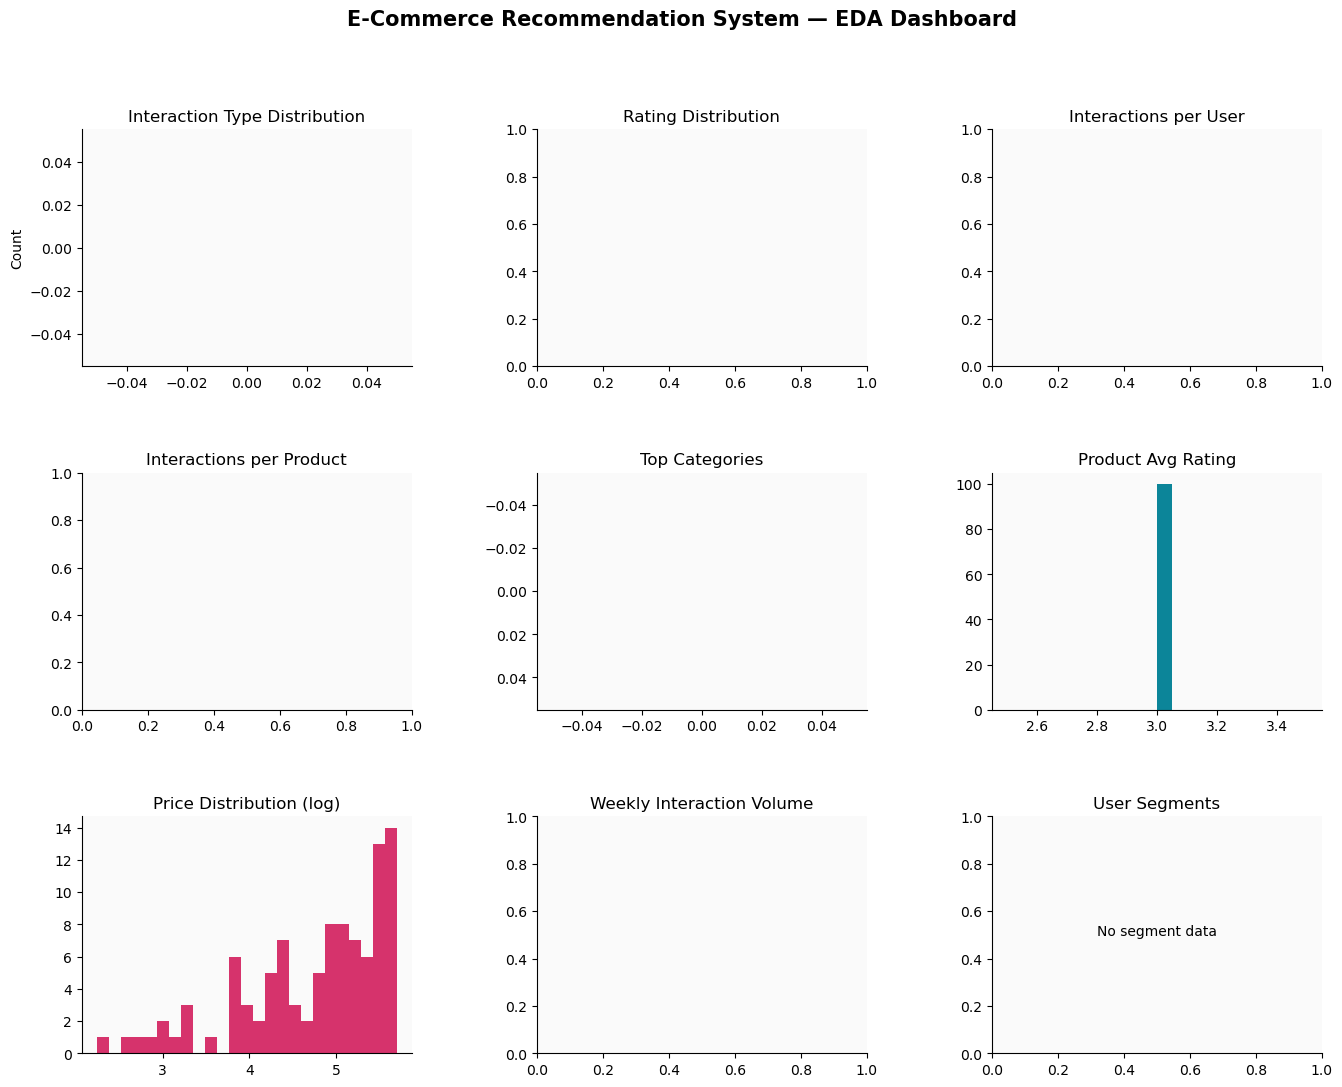

✅ EDA chart saved → evaluation/eda_dashboard.png


In [27]:
# ════════════════════════════════════════════════════════
#   CORE METRICS (SAFE)
# ════════════════════════════════════════════════════════

uic = interactions_df.groupby('userId').size()
pic = interactions_df.groupby('productId').size()

n_u = interactions_df['userId'].nunique()
n_p = interactions_df['productId'].nunique()

# Safe sparsity
denominator = n_u * n_p
if denominator == 0:
    sparsity = 1.0
else:
    unique_pairs = interactions_df.groupby(['userId', 'productId']).size()
    sparsity = 1 - len(unique_pairs) / denominator

cold_u = (uic <= CONFIG['min_user_interactions']).sum() if len(uic) else 0
cold_p = (pic <= 1).sum() if len(pic) else 0

rated = interactions_df[interactions_df['rating'].notna()] \
        if 'rating' in interactions_df.columns else pd.DataFrame()

# ════════════════════════════════════════════════════════
#   SUMMARY PRINT
# ════════════════════════════════════════════════════════

print('='*55)
print('  EDA SUMMARY')
print('='*55)
print(f'  Total interactions      : {len(interactions_df):>8,}')
print(f'  Unique users            : {n_u:>8,}')
print(f'  Unique products         : {n_p:>8,}')
print(f'  Matrix sparsity         : {sparsity*100:>7.1f} %')
print(f'  Avg interactions/user   : {uic.mean() if len(uic) else 0:>7.1f}')
print(f'  Max interactions/user   : {uic.max() if len(uic) else 0:>7}')
print(f'  Cold-start users (≤{CONFIG["min_user_interactions"]})  : {cold_u:>8,}  ({(100*cold_u/n_u) if n_u else 0:.1f} %)')
print(f'  Cold-start products (≤1): {cold_p:>8,}  ({(100*cold_p/n_p) if n_p else 0:.1f} %)')

if len(rated):
    print(f'  Avg explicit rating     : {rated["rating"].mean():>7.2f}')

print('='*55)


# ════════════════════════════════════════════════════════
#   9-PANEL EDA DASHBOARD (SAFE)
# ════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Interaction Type Distribution ──
ax1 = fig.add_subplot(gs[0,0])
cnt = interactions_df['interaction'].value_counts() if 'interaction' in interactions_df.columns else pd.Series()
bars = ax1.bar(cnt.index, cnt.values, color=PALETTE[:len(cnt)], edgecolor='white')
ax1.set_title('Interaction Type Distribution')
ax1.set_ylabel('Count')

for bar, v in zip(bars, cnt.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{v:,}', ha='center', fontsize=9)

# ── Rating Distribution ──
ax2 = fig.add_subplot(gs[0,1])
if len(rated):
    rv = rated['rating'].value_counts().sort_index()
    ax2.bar(rv.index.astype(str), rv.values, color=PALETTE[1])
    ax2.axhline(rv.mean(), linestyle='--', label=f'Mean: {rated["rating"].mean():.2f}')
    ax2.legend(fontsize=9)
ax2.set_title('Rating Distribution')

# ── Interactions per User ──
ax3 = fig.add_subplot(gs[0,2])
if len(uic):
    ax3.hist(uic.values, bins=min(40, len(uic)), color=PALETTE[2])
    ax3.axvline(uic.median(), linestyle='--', label=f'Median: {uic.median():.0f}')
    ax3.legend(fontsize=9)
ax3.set_title('Interactions per User')

# ── Interactions per Product ──
ax4 = fig.add_subplot(gs[1,0])
if len(pic):
    ax4.hist(pic.values, bins=min(40, len(pic)), color=PALETTE[3])
ax4.set_title('Interactions per Product')

# ── Top Categories ──
ax5 = fig.add_subplot(gs[1,1])
if 'category' in products_df.columns:
    merged = interactions_df.merge(products_df[['productId','category']], on='productId', how='left')
    cat_cnt = merged['category'].value_counts().head(10)
    ax5.barh(cat_cnt.index, cat_cnt.values, color=PALETTE[4])
    ax5.invert_yaxis()
ax5.set_title('Top Categories')

# ── Product Ratings ──
ax6 = fig.add_subplot(gs[1,2])
if 'avgRating' in products_df.columns:
    vals = products_df['avgRating'].dropna()
    if len(vals):
        ax6.hist(vals, bins=20, color=PALETTE[5])
ax6.set_title('Product Avg Rating')

# ── Price Distribution ──
ax7 = fig.add_subplot(gs[2,0])
if 'price' in products_df.columns:
    price_vals = products_df['price'].dropna()
    if len(price_vals) and price_vals.max() > 0:
        ax7.hist(np.log1p(price_vals), bins=25, color=PALETTE[6])
ax7.set_title('Price Distribution (log)')

# ── Weekly Interactions ──
ax8 = fig.add_subplot(gs[2,1])
if 'timestamp' in interactions_df.columns:
    interactions_df['_dt'] = pd.to_datetime(interactions_df['timestamp'], errors='coerce')
    valid_ts = interactions_df.dropna(subset=['_dt']).set_index('_dt')
    if len(valid_ts):
        weekly = valid_ts.resample('W').size()
        ax8.plot(weekly.index, weekly.values, color=PALETTE[7])
        ax8.fill_between(weekly.index, weekly.values, alpha=0.2)
        plt.setp(ax8.xaxis.get_majorticklabels(), rotation=30)
ax8.set_title('Weekly Interaction Volume')

# ── User Segments ──
ax9 = fig.add_subplot(gs[2,2])
if 'segment' in users_df.columns:
    seg_vals = users_df['segment'].value_counts()
    if len(seg_vals) > 1:
        ax9.pie(seg_vals.values, labels=seg_vals.index,
                autopct='%1.1f%%', colors=PALETTE[:len(seg_vals)])
    else:
        ax9.text(0.5, 0.5, 'No segment data', ha='center')
ax9.set_title('User Segments')

# ── Finalize ──
fig.suptitle('E-Commerce Recommendation System — EDA Dashboard',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation/eda_dashboard.png', dpi=150)
plt.show()

print('✅ EDA chart saved → evaluation/eda_dashboard.png')

No explicit ratings found — using implicit signals only
Preprocessing complete
  Full matrix shape    : (0, 0)
  Train matrix shape   : (0, 0)
  Matrix sparsity      : nan %
  Aggregated pairs     : 0
  Test ground-truth    : 0 users with purchases/reviews in test set
  TF-IDF features      : 200


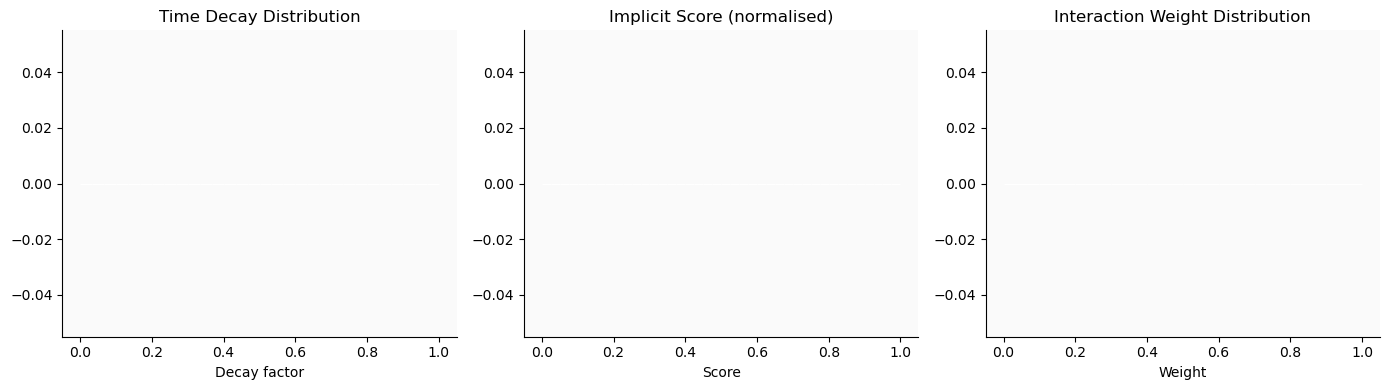

In [28]:
HALF_LIFE_DAYS = 90  # interactions older than 90 days score at half weight

# ── 1. Time-decay ─────────────────────────────────────────────────────────────
now_ts = time.time()
interactions_df['age_days']   = (now_ts - interactions_df['timestamp']) / 86400
interactions_df['age_days']   = interactions_df['age_days'].clip(lower=0)
interactions_df['time_decay'] = np.exp(-np.log(2) * interactions_df['age_days'] / HALF_LIFE_DAYS)

# ── 2. Implicit score ─────────────────────────────────────────────────────────
interactions_df['iw']    = interactions_df['interaction'].map(INTERACTION_WEIGHTS).fillna(1.0)
interactions_df['qty']   = pd.to_numeric(interactions_df['quantity'],errors='coerce').fillna(1).clip(1,20)
interactions_df['score'] = interactions_df['iw'] * interactions_df['time_decay'] * np.log1p(interactions_df['qty'])

# ── 3. Aggregate: take max score per (user, product) pair ─────────────────────
agg = (interactions_df
       .groupby(['userId','productId'])['score']
       .max().reset_index()
       .rename(columns={'score':'implicit_score'}))

# ── 4. Per-user normalisation ─────────────────────────────────────────────────
def minmax_user(grp):
    mn, mx = grp.min(), grp.max()
    return (grp - mn) / (mx - mn + 1e-9)

agg['implicit_score'] = agg.groupby('userId')['implicit_score'].transform(minmax_user)

# ── 5. Explicit ratings dataframe ─────────────────────────────────────────────
rated = interactions_df[interactions_df['rating'].notna()].copy()
if len(rated) > 0:
    ratings_df = (rated.groupby(['userId','productId'])['rating']
                  .mean().reset_index()
                  .rename(columns={'rating':'explicit_rating'}))
    print(f'Explicit rating pairs  : {len(ratings_df):,}')
else:
    ratings_df = pd.DataFrame(columns=['userId','productId','explicit_rating'])
    print('No explicit ratings found — using implicit signals only')

# ── 6. Time-based train / test split ──────────────────────────────────────────
interactions_sorted = interactions_df.sort_values('timestamp').reset_index(drop=True)
split_idx  = int(len(interactions_sorted) * (1 - CONFIG['test_size']))
train_raw  = interactions_sorted.iloc[:split_idx].copy()
test_raw   = interactions_sorted.iloc[split_idx:].copy()

train_agg  = (train_raw.groupby(['userId','productId'])['score']
              .max().reset_index()
              .rename(columns={'score':'implicit_score'}))
train_agg['implicit_score'] = train_agg.groupby('userId')['implicit_score'].transform(minmax_user)

# ── 7. Build user × product matrices ──────────────────────────────────────────
ALL_USERS    = sorted(agg['userId'].unique().tolist())
ALL_PRODUCTS = sorted(agg['productId'].unique().tolist())
uid2idx      = {u: i for i, u in enumerate(ALL_USERS)}
pid2idx      = {p: i for i, p in enumerate(ALL_PRODUCTS)}

def build_matrix(df_agg, users, products, u2i, p2i):
    mat = np.zeros((len(users), len(products)), dtype=np.float32)
    for row in df_agg.itertuples(index=False):
        i = u2i.get(row.userId)
        j = p2i.get(row.productId)
        if i is not None and j is not None:
            mat[i, j] = row.implicit_score
    return mat

full_matrix  = build_matrix(agg,       ALL_USERS, ALL_PRODUCTS, uid2idx, pid2idx)
train_matrix = build_matrix(train_agg, ALL_USERS, ALL_PRODUCTS, uid2idx, pid2idx)

# ── 8. Seen products per user ──────────────────────────────────────────────────
user_seen = agg.groupby('userId')['productId'].apply(set).to_dict()

# ── 9. Test ground truth ───────────────────────────────────────────────────────
test_gt = (test_raw[test_raw['interaction'].isin(['purchase','review'])]
           .groupby('userId')['productId'].apply(set).to_dict())

# ── 10. TF-IDF content features ───────────────────────────────────────────────
products_df['text_feature'] = (
    products_df['name'].fillna('') + ' ' +
    products_df['category'].fillna('') + ' ' +
    products_df['brand'].fillna('') + ' ' +
    products_df['tags'].fillna('') + ' ' +
    products_df['description'].fillna('')
)
n_tfidf_features = min(500, max(50, len(products_df) * 2))
tfidf_vec     = TfidfVectorizer(max_features=n_tfidf_features, stop_words='english',
                                 ngram_range=(1,2), sublinear_tf=True)
tfidf_matrix  = tfidf_vec.fit_transform(products_df['text_feature'])
content_sim   = cosine_similarity(tfidf_matrix, tfidf_matrix)
tfidf_pids    = products_df['productId'].tolist()
tfidf_pid2idx = {p: i for i, p in enumerate(tfidf_pids)}

# ── 11. Popularity scores ──────────────────────────────────────────────────────
_rating_v = products_df['avgRating'].fillna(3.0).values.reshape(-1,1)
_review_v = np.log1p(products_df['numReviews'].fillna(0).values.reshape(-1,1))
_pop_raw  = _rating_v * _review_v
_pop_max  = _pop_raw.max()
products_df['pop_score'] = (_pop_raw / (_pop_max + 1e-9)).flatten()
popularity_scores = dict(zip(products_df['productId'], products_df['pop_score']))

print(f'Preprocessing complete')
print(f'  Full matrix shape    : {full_matrix.shape}')
print(f'  Train matrix shape   : {train_matrix.shape}')
print(f'  Matrix sparsity      : {(full_matrix==0).mean()*100:.1f} %')
print(f'  Aggregated pairs     : {len(agg):,}')
print(f'  Test ground-truth    : {len(test_gt):,} users with purchases/reviews in test set')
print(f'  TF-IDF features      : {tfidf_matrix.shape[1]}')

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(interactions_df['time_decay'], bins=30, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Time Decay Distribution'); axes[0].set_xlabel('Decay factor')
axes[1].hist(agg['implicit_score'], bins=40, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Implicit Score (normalised)'); axes[1].set_xlabel('Score')
axes[2].hist(interactions_df['iw'], bins=10, color=PALETTE[2], edgecolor='white')
axes[2].set_title('Interaction Weight Distribution'); axes[2].set_xlabel('Weight')
plt.tight_layout(); plt.show()


In [17]:
print("train_matrix shape:", train_matrix.shape)
print("non-zero entries:", train_matrix.nnz if hasattr(train_matrix, "nnz") else np.count_nonzero(train_matrix))

train_matrix shape: (0, 0)
non-zero entries: 0


In [29]:
# Auto-select SVD factors if dataset is small
max_possible_factors = min(train_matrix.shape[0]-1, train_matrix.shape[1]-1, CONFIG['svd_factors'])
N_FACTORS = max(5, max_possible_factors)
if N_FACTORS < CONFIG['svd_factors']:
    print(f'[INFO] Reducing SVD factors from {CONFIG["svd_factors"]} to {N_FACTORS} '
          f'(dataset size limit)')

svd_model    = TruncatedSVD(n_components=N_FACTORS, algorithm='randomized',
                             n_iter=10, random_state=CONFIG['random_seed'])
user_factors = svd_model.fit_transform(train_matrix)  # (n_users x k)
item_factors = svd_model.components_.T                 # (n_products x k)
explained    = svd_model.explained_variance_ratio_.cumsum()

print(f'SVD complete')
print(f'  User factors shape  : {user_factors.shape}')
print(f'  Item factors shape  : {item_factors.shape}')
print(f'  Variance explained  : {explained[-1]*100:.2f}% with {N_FACTORS} factors')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
top = min(25, N_FACTORS)
axes[0].bar(range(1,top+1), svd_model.explained_variance_ratio_[:top]*100,
            color=PALETTE[0], edgecolor='white')
axes[0].set_title(f'Variance per Factor (top {top})')
axes[0].set_xlabel('SVD Factor'); axes[0].set_ylabel('Explained variance (%)')

axes[1].plot(range(1,N_FACTORS+1), explained*100, color=PALETTE[1],
             linewidth=2, marker='o', markersize=3)
axes[1].axhline(80, color='#E03131', linestyle='--', linewidth=1, label='80% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Factors'); axes[1].set_ylabel('Cumulative (%)')
axes[1].legend()
plt.tight_layout(); plt.show()

# 2D product latent space
if N_FACTORS >= 2 and len(products_df) <= 2000:
    pca_2d  = PCA(n_components=2, random_state=42)
    items2d = pca_2d.fit_transform(item_factors)
    cat_labels = products_df['category'].values
    uniq_cats  = list(dict.fromkeys(cat_labels))[:10]
    fig, ax = plt.subplots(figsize=(11, 6))
    for i, cat in enumerate(uniq_cats):
        mask = np.array(cat_labels) == cat
        ax.scatter(items2d[mask,0], items2d[mask,1],
                   c=PALETTE[i % len(PALETTE)], label=cat, s=20, alpha=0.7, edgecolors='none')
    ax.set_title('Product Latent Space (SVD → PCA 2D)\nCloser = more similar')
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
    ax.legend(loc='best', fontsize=8, ncol=2, framealpha=0.7)
    plt.tight_layout(); plt.show()


[INFO] Reducing SVD factors from 50 to 5 (dataset size limit)


ValueError: Found array with 0 sample(s) (shape=(0, 0)) while a minimum of 1 is required by TruncatedSVD.

In [30]:
K = min(CONFIG['knn_k'], len(ALL_USERS)-1)  # can't have more neighbours than users

# User-based KNN
knn_user = NearestNeighbors(
    n_neighbors=K+1, metric='cosine', algorithm='brute', n_jobs=-1
)
knn_user.fit(user_factors)
print(f'User-based KNN fitted  (K={K}, metric=cosine)')

# Item-based KNN
K_item = min(CONFIG['knn_k'], len(ALL_PRODUCTS)-1)
knn_item = NearestNeighbors(
    n_neighbors=K_item+1, metric='cosine', algorithm='brute', n_jobs=-1
)
knn_item.fit(item_factors)
print(f'Item-based KNN fitted  (K={K_item}, metric=cosine)')

def user_based_cf_scores(user_idx):
    vec = user_factors[user_idx].reshape(1,-1)
    dists, nb_idx = knn_user.kneighbors(vec)
    dists, nb_idx = dists[0], nb_idx[0]
    mask = nb_idx != user_idx
    dists, nb_idx = dists[mask], nb_idx[mask]
    sims   = np.clip(1 - dists, 0, 1)
    scores = np.dot(sims, train_matrix[nb_idx])
    return scores / (sims.sum() + 1e-9)

def item_based_cf_scores(user_idx):
    user_row  = train_matrix[user_idx]
    pos_items = np.where(user_row > 0)[0]
    if len(pos_items) == 0:
        return np.zeros(len(ALL_PRODUCTS), dtype=np.float32)
    scores = np.zeros(len(ALL_PRODUCTS), dtype=np.float32)
    for item_idx in pos_items:
        vec = item_factors[item_idx].reshape(1,-1)
        dists, nb_idx = knn_item.kneighbors(vec)
        dists, nb_idx = dists[0][1:], nb_idx[0][1:]
        sims  = np.clip(1 - dists, 0, 1)
        scores[nb_idx] += sims * user_row[item_idx]
    return scores

# Demo: similar users
if len(ALL_USERS) > 5:
    demo_uid = ALL_USERS[0]
    demo_idx = uid2idx[demo_uid]
    vec      = user_factors[demo_idx].reshape(1,-1)
    dists, nb = knn_user.kneighbors(vec)
    print(f'\n3 most similar users to [{demo_uid}]:')
    for i in range(1, min(4, len(nb[0]))):
        u2  = ALL_USERS[nb[0][i]]
        sim = (1 - dists[0][i]) * 100
        seg = users_df.loc[users_df['userId']==u2,'segment'].values
        seg_str = seg[0] if len(seg) else 'n/a'
        print(f'  {u2}  similarity={sim:.1f}%  segment={seg_str}')

# Heatmap of first 50 users
n_heat = min(50, len(user_factors))
sim_heat = cosine_similarity(user_factors[:n_heat])
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(sim_heat, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label':'Cosine similarity'})
ax.set_title(f'User-User Cosine Similarity Heatmap (first {n_heat} users)')
plt.tight_layout(); plt.show()


NameError: name 'user_factors' is not defined

In [31]:
# Auto-select SVD factors if dataset is small
max_possible_factors = min(train_matrix.shape[0]-1, train_matrix.shape[1]-1, CONFIG['svd_factors'])
N_FACTORS = max(5, max_possible_factors)
if N_FACTORS < CONFIG['svd_factors']:
    print(f'[INFO] Reducing SVD factors from {CONFIG["svd_factors"]} to {N_FACTORS} '
          f'(dataset size limit)')

svd_model    = TruncatedSVD(n_components=N_FACTORS, algorithm='randomized',
                             n_iter=10, random_state=CONFIG['random_seed'])
user_factors = svd_model.fit_transform(train_matrix)  # (n_users x k)
item_factors = svd_model.components_.T                 # (n_products x k)
explained    = svd_model.explained_variance_ratio_.cumsum()

print(f'SVD complete')
print(f'  User factors shape  : {user_factors.shape}')
print(f'  Item factors shape  : {item_factors.shape}')
print(f'  Variance explained  : {explained[-1]*100:.2f}% with {N_FACTORS} factors')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
top = min(25, N_FACTORS)
axes[0].bar(range(1,top+1), svd_model.explained_variance_ratio_[:top]*100,
            color=PALETTE[0], edgecolor='white')
axes[0].set_title(f'Variance per Factor (top {top})')
axes[0].set_xlabel('SVD Factor'); axes[0].set_ylabel('Explained variance (%)')

axes[1].plot(range(1,N_FACTORS+1), explained*100, color=PALETTE[1],
             linewidth=2, marker='o', markersize=3)
axes[1].axhline(80, color='#E03131', linestyle='--', linewidth=1, label='80% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Factors'); axes[1].set_ylabel('Cumulative (%)')
axes[1].legend()
plt.tight_layout(); plt.show()

# 2D product latent space
if N_FACTORS >= 2 and len(products_df) <= 2000:
    pca_2d  = PCA(n_components=2, random_state=42)
    items2d = pca_2d.fit_transform(item_factors)
    cat_labels = products_df['category'].values
    uniq_cats  = list(dict.fromkeys(cat_labels))[:10]
    fig, ax = plt.subplots(figsize=(11, 6))
    for i, cat in enumerate(uniq_cats):
        mask = np.array(cat_labels) == cat
        ax.scatter(items2d[mask,0], items2d[mask,1],
                   c=PALETTE[i % len(PALETTE)], label=cat, s=20, alpha=0.7, edgecolors='none')
    ax.set_title('Product Latent Space (SVD → PCA 2D)\nCloser = more similar')
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
    ax.legend(loc='best', fontsize=8, ncol=2, framealpha=0.7)
    plt.tight_layout(); plt.show()


[INFO] Reducing SVD factors from 50 to 5 (dataset size limit)


ValueError: Found array with 0 sample(s) (shape=(0, 0)) while a minimum of 1 is required by TruncatedSVD.

In [32]:
def content_based_scores(interacted_pids, exclude=None):
    """Score all products by similarity to user's interacted products."""
    exclude   = exclude or set()
    score_agg = np.zeros(len(tfidf_pids), dtype=np.float32)
    for pid in interacted_pids:
        i = tfidf_pid2idx.get(pid)
        if i is not None:
            score_agg += content_sim[i]
    for pid in list(interacted_pids) + list(exclude):
        j = tfidf_pid2idx.get(pid)
        if j is not None:
            score_agg[j] = 0.0
    return {tfidf_pids[i]: float(score_agg[i]) for i in range(len(tfidf_pids))}

print('Content-based filter ready (TF-IDF cosine)')

# Demo: products similar to the first product
demo_pid  = products_df['productId'].iloc[0]
demo_name = products_df.loc[products_df['productId']==demo_pid,'name'].values[0]
cb_scores = content_based_scores([demo_pid])
top5_cb   = sorted(cb_scores.items(), key=lambda x: x[1], reverse=True)[:5]
print(f'\nTop-5 products similar to: [{demo_pid}] {demo_name[:50]}')
print('-'*70)
for pid, sc in top5_cb:
    row = products_df[products_df['productId']==pid]
    if len(row):
        print(f'  {pid:12s}  score={sc:.4f}  '
              f'cat={row["category"].values[0]:20s}  {row["name"].values[0][:40]}')


Content-based filter ready (TF-IDF cosine)

Top-5 products similar to: [prod_0001] Wireless Earbuds
----------------------------------------------------------------------
  prod_0004     score=0.2677  cat=Electronics           Mechanical Keyboard
  prod_0012     score=0.2677  cat=Electronics           Laptop Stand
  prod_0002     score=0.2423  cat=Electronics           Bluetooth Speaker
  prod_0003     score=0.2423  cat=Electronics           USB-C Hub
  prod_0007     score=0.2423  cat=Electronics           Portable Charger


In [33]:
def get_weights(n_interactions):
    if n_interactions < 3:
        return {'user_cf':0.05,'item_cf':0.05,'content':0.30,'popularity':0.60}
    elif n_interactions < 10:
        return {'user_cf':0.25,'item_cf':0.25,'content':0.30,'popularity':0.20}
    else:
        return {'user_cf':0.40,'item_cf':0.35,'content':0.20,'popularity':0.05}

def recommend(user_id, top_n=None, weights=None):
    """
    Generate product recommendations for a user.

    Parameters
    ----------
    user_id  : str   MongoDB userId as string
    top_n    : int   How many products to return (default: CONFIG['top_n'])
    weights  : dict  Override adaptive weights (optional)

    Returns
    -------
    list of dicts: [{productId, name, category, score, reason, coldStart}]
    """
    if top_n is None:
        top_n = CONFIG['top_n']

    user_idx   = uid2idx.get(str(user_id))
    seen       = user_seen.get(str(user_id), set())
    n_inter    = len(seen)
    is_cold    = n_inter < CONFIG['min_user_interactions']
    w          = weights or get_weights(n_inter)
    scores     = defaultdict(float)
    reason_map = {}

    # ── User-CF ──────────────────────────────────────────────────────────
    if user_idx is not None and w['user_cf'] > 0:
        ucf   = user_based_cf_scores(user_idx)
        max_s = ucf.max() + 1e-9
        for j, s in enumerate(ucf):
            if s > 0:
                pid = ALL_PRODUCTS[j]
                scores[pid] += w['user_cf'] * (s / max_s)
                reason_map.setdefault(pid, 'user_cf')

    # ── Item-CF ──────────────────────────────────────────────────────────
    if user_idx is not None and w['item_cf'] > 0:
        icf   = item_based_cf_scores(user_idx)
        max_s = icf.max() + 1e-9
        for j, s in enumerate(icf):
            if s > 0:
                pid = ALL_PRODUCTS[j]
                scores[pid] += w['item_cf'] * (s / max_s)
                reason_map.setdefault(pid, 'item_cf')

    # ── Content-based ─────────────────────────────────────────────────────
    if w['content'] > 0 and len(seen) > 0:
        cb    = content_based_scores(list(seen)[:30])
        max_s = max(cb.values()) + 1e-9 if cb else 1
        for pid, s in cb.items():
            scores[pid] += w['content'] * (s / max_s)
            reason_map.setdefault(pid, 'content')

    # ── Popularity ────────────────────────────────────────────────────────
    if w['popularity'] > 0:
        for pid, s in popularity_scores.items():
            if pid not in seen:
                scores[pid] += w['popularity'] * s
                reason_map.setdefault(pid, 'popularity')

    # ── Remove already-seen ───────────────────────────────────────────────
    for pid in seen:
        scores.pop(pid, None)

    # ── Rank ──────────────────────────────────────────────────────────────
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    results = []
    for pid, sc in ranked:
        row  = products_df[products_df['productId'] == pid]
        name = row['name'].values[0]     if len(row) else pid
        cat  = row['category'].values[0] if len(row) else 'Unknown'
        results.append({
            'productId': pid,
            'name':      name,
            'category':  cat,
            'score':     round(float(sc), 5),
            'reason':    reason_map.get(pid, 'mixed'),
            'coldStart': is_cold,
        })
    return results

# ── Demo recommendations ──────────────────────────────────────────────────────
print('Sample recommendations:')
print('='*80)
for demo_uid in ALL_USERS[:3]:
    recs = recommend(demo_uid, top_n=5)
    n_s  = len(user_seen.get(demo_uid, set()))
    print(f'User: {demo_uid}  |  interactions seen: {n_s}  |  weights: {get_weights(n_s)}')
    for r in recs:
        print(f'  {r["productId"]:15s}  score={r["score"]:.5f}  '
              f'reason={r["reason"]:12s}  {r["name"][:45]}')
    print()
print('Hybrid recommender ready')


Sample recommendations:
Hybrid recommender ready


In [34]:
def precision_at_k(recommended, relevant, k):
    return len(set(recommended[:k]) & relevant) / k if k else 0.0

def recall_at_k(recommended, relevant, k):
    return len(set(recommended[:k]) & relevant) / len(relevant) if relevant else 0.0

def ndcg_at_k(recommended, relevant, k):
    dcg  = sum(1.0/np.log2(i+2) for i,p in enumerate(recommended[:k]) if p in relevant)
    idcg = sum(1.0/np.log2(i+2) for i in range(min(len(relevant), k)))
    return dcg/idcg if idcg > 0 else 0.0

def avg_diversity(recs, sim_matrix, p2idx_map):
    pids = [r['productId'] for r in recs]
    idx  = [p2idx_map[p] for p in pids if p in p2idx_map]
    if len(idx) < 2: return 0.0
    total, count = 0.0, 0
    for a in range(len(idx)):
        for b in range(a+1, len(idx)):
            total += sim_matrix[idx[a], idx[b]]
            count += 1
    return 1.0 - (total/count if count else 0.0)

def evaluate(gt, k=10, n_samples=200, verbose=True):
    sample   = list(gt.keys())[:n_samples]
    P, R, F, N, D = [], [], [], [], []
    all_recs = set()
    for uid in sample:
        rel  = gt[uid]
        recs = recommend(uid, top_n=k)
        pids = [r['productId'] for r in recs]
        all_recs.update(pids)
        p = precision_at_k(pids, rel, k)
        r = recall_at_k(pids, rel, k)
        f = 2*p*r/(p+r) if (p+r) else 0
        n = ndcg_at_k(pids, rel, k)
        d = avg_diversity(recs, content_sim, tfidf_pid2idx)
        P.append(p); R.append(r); F.append(f); N.append(n); D.append(d)
    cov     = len(all_recs) / len(ALL_PRODUCTS)
    metrics = {
        f'precision@{k}':   round(float(np.mean(P)), 5),
        f'recall@{k}':      round(float(np.mean(R)), 5),
        f'f1@{k}':          round(float(np.mean(F)), 5),
        f'ndcg@{k}':        round(float(np.mean(N)), 5),
        'diversity':        round(float(np.mean(D)), 5),
        'catalog_coverage': round(cov, 5),
        'n_test_users':     len(sample),
    }
    if verbose:
        print('='*52)
        print(f'  EVALUATION RESULTS  (K={k}, n={len(sample)} users)')
        print('='*52)
        for key, val in metrics.items():
            print(f'  {key:<24s}: {val}')
        print('='*52)
    return metrics

eval_metrics = evaluate(test_gt, k=CONFIG['top_n'], n_samples=300, verbose=True)

# Per-model comparison
print('\nPer-model comparison (first 100 test users):')
def eval_w(w, label):
    P, R, N_v = [], [], []
    for uid in list(test_gt.keys())[:100]:
        rel  = test_gt[uid]
        recs = recommend(uid, top_n=CONFIG['top_n'], weights=w)
        pids = [r['productId'] for r in recs]
        P.append(precision_at_k(pids,rel,CONFIG['top_n']))
        R.append(recall_at_k(pids,rel,CONFIG['top_n']))
        N_v.append(ndcg_at_k(pids,rel,CONFIG['top_n']))
    k=CONFIG['top_n']
    print(f'  {label:<26s}  P@{k}={np.mean(P):.4f}  R@{k}={np.mean(R):.4f}  NDCG@{k}={np.mean(N_v):.4f}')

eval_w({'user_cf':1,'item_cf':0,'content':0,'popularity':0}, 'User-CF only')
eval_w({'user_cf':0,'item_cf':1,'content':0,'popularity':0}, 'Item-CF only')
eval_w({'user_cf':0,'item_cf':0,'content':1,'popularity':0}, 'Content-based only')
eval_w({'user_cf':0,'item_cf':0,'content':0,'popularity':1}, 'Popularity only')
eval_w({'user_cf':0.40,'item_cf':0.35,'content':0.20,'popularity':0.05}, 'Hybrid (active user)')

# Metrics-vs-K chart
K_VALUES = [1,3,5,10,15,20]
P_v,R_v,N_v=[],[],[]
sample_u = list(test_gt.keys())[:150]
for k in K_VALUES:
    Pk,Rk,Nk=[],[],[]
    for uid in sample_u:
        rel  = test_gt[uid]
        recs = recommend(uid, top_n=max(K_VALUES))
        pids = [r['productId'] for r in recs]
        Pk.append(precision_at_k(pids,rel,k))
        Rk.append(recall_at_k(pids,rel,k))
        Nk.append(ndcg_at_k(pids,rel,k))
    P_v.append(np.mean(Pk)); R_v.append(np.mean(Rk)); N_v.append(np.mean(Nk))

fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax, vals, lbl, col in [(axes[0],P_v,'Precision@K',PALETTE[0]),
                            (axes[1],R_v,'Recall@K',   PALETTE[1]),
                            (axes[2],N_v,'NDCG@K',     PALETTE[2])]:
    ax.plot(K_VALUES, vals, marker='o', color=col, linewidth=2)
    ax.fill_between(K_VALUES, vals, alpha=0.15, color=col)
    ax.set_title(lbl); ax.set_xlabel('K'); ax.grid(alpha=0.3)
plt.suptitle('Recommendation Quality vs K', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


ZeroDivisionError: division by zero

In [35]:
K_GRID      = [5, 10, 20, 40]
FACTOR_GRID = [20, 50, 100]
TUNE_USERS  = list(test_gt.keys())[:80]
results_grid, best_ndcg, best_params = [], -1, {}

print(f'{"K":>5}  {"Factors":>8}  {"Precision@10":>13}  {"Recall@10":>10}  {"NDCG@10":>9}')
print('-'*55)

for k_val in K_GRID:
    for n_f in FACTOR_GRID:
        n_f_adj = min(n_f, train_matrix.shape[0]-1, train_matrix.shape[1]-1)
        if n_f_adj < 2: continue
        _svd = TruncatedSVD(n_components=n_f_adj, random_state=42)
        _uf  = _svd.fit_transform(train_matrix)
        _knn = NearestNeighbors(n_neighbors=min(k_val+1,len(_uf)),
                                metric='cosine', algorithm='brute')
        _knn.fit(_uf)
        P, R, Nv = [], [], []
        for uid in TUNE_USERS:
            rel  = test_gt[uid]
            uidx = uid2idx.get(uid)
            if uidx is None: continue
            vec  = _uf[uidx].reshape(1,-1)
            ds, nb = _knn.kneighbors(vec)
            ds, nb = ds[0][1:], nb[0][1:]
            sims = np.clip(1-ds, 0, 1)
            ucf  = np.dot(sims, train_matrix[nb]) / (sims.sum()+1e-9)
            ucf /= (ucf.max()+1e-9)
            seen = user_seen.get(uid, set())
            pids = [ALL_PRODUCTS[j] for j in np.argsort(ucf)[::-1]
                    if ALL_PRODUCTS[j] not in seen][:CONFIG['top_n']]
            P.append(precision_at_k(pids,rel,CONFIG['top_n']))
            R.append(recall_at_k(pids,rel,CONFIG['top_n']))
            Nv.append(ndcg_at_k(pids,rel,CONFIG['top_n']))
        if not P: continue
        mp,mr,mn = np.mean(P),np.mean(R),np.mean(Nv)
        results_grid.append({'K':k_val,'factors':n_f_adj,'ndcg':mn,'precision':mp,'recall':mr})
        print(f'{k_val:>5}  {n_f_adj:>8}  {mp:>13.5f}  {mr:>10.5f}  {mn:>9.5f}')
        if mn > best_ndcg:
            best_ndcg, best_params = mn, {'K':k_val,'factors':n_f_adj}

print(f'\nBest params: {best_params}  =>  NDCG@10 = {best_ndcg:.5f}')

# Heatmap
if len(results_grid) >= 4:
    grid_df = pd.DataFrame(results_grid)
    try:
        pivot = grid_df.pivot(index='factors', columns='K', values='ndcg')
        fig, ax = plt.subplots(figsize=(8,4))
        sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                    linewidths=0.5, ax=ax, cbar_kws={'label':'NDCG@10'})
        ax.set_title('Hyperparameter Tuning — NDCG@10 (SVD Factors x KNN K)')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f'Heatmap skipped: {e}')

print(f'\n[TIP] Update CONFIG["knn_k"]={best_params.get("K",CONFIG["knn_k"])} and '
      f'CONFIG["svd_factors"]={best_params.get("factors",CONFIG["svd_factors"])} '
      f'for best performance on your dataset.')


    K   Factors   Precision@10   Recall@10    NDCG@10
-------------------------------------------------------

Best params: {}  =>  NDCG@10 = -1.00000

[TIP] Update CONFIG["knn_k"]=20 and CONFIG["svd_factors"]=50 for best performance on your dataset.


In [36]:
N_SPLITS = 5
CV_USERS = 80
sorted_ints = interactions_df.sort_values('timestamp').reset_index(drop=True)
fold_size   = len(sorted_ints) // N_SPLITS
cv_results  = []

print(f'{N_SPLITS}-fold time-aware cross-validation...')
print(f'{"Fold":>5}  {"P@K":>8}  {"R@K":>8}  {"NDCG@K":>8}  {"Coverage":>9}')
print('-'*50)

for fold in range(N_SPLITS):
    train_end  = fold_size * (fold+1)
    fold_train = sorted_ints.iloc[:train_end]
    fold_test  = sorted_ints.iloc[train_end:train_end+fold_size]
    if len(fold_test) == 0: continue

    f_agg = (fold_train.groupby(['userId','productId'])['score']
             .max().reset_index().rename(columns={'score':'implicit_score'}))
    f_agg['implicit_score'] = f_agg.groupby('userId')['implicit_score'].transform(minmax_user)
    f_mat = build_matrix(f_agg, ALL_USERS, ALL_PRODUCTS, uid2idx, pid2idx)

    n_f_cv = min(N_FACTORS, f_mat.shape[0]-1, f_mat.shape[1]-1)
    if n_f_cv < 2: continue
    f_svd = TruncatedSVD(n_components=n_f_cv, random_state=42)
    f_uf  = f_svd.fit_transform(f_mat)
    f_knn = NearestNeighbors(n_neighbors=min(K+1,len(f_uf)),
                              metric='cosine', algorithm='brute')
    f_knn.fit(f_uf)

    f_gt   = (fold_test[fold_test['interaction'].isin(['purchase','review'])]
              .groupby('userId')['productId'].apply(set).to_dict())
    f_seen = f_agg.groupby('userId')['productId'].apply(set).to_dict()

    P, R, Nv = [], [], []
    all_recs_fold = set()
    for uid in list(f_gt.keys())[:CV_USERS]:
        uidx = uid2idx.get(uid)
        if uidx is None: continue
        rel  = f_gt[uid]
        vec  = f_uf[uidx].reshape(1,-1)
        ds, nb = f_knn.kneighbors(vec)
        ds, nb = ds[0][1:], nb[0][1:]
        sims   = np.clip(1-ds, 0, 1)
        ucf    = np.dot(sims, f_mat[nb]) / (sims.sum()+1e-9)
        pids   = [ALL_PRODUCTS[j] for j in np.argsort(ucf)[::-1]
                  if ALL_PRODUCTS[j] not in f_seen.get(uid,set())][:CONFIG['top_n']]
        all_recs_fold.update(pids)
        P.append(precision_at_k(pids,rel,CONFIG['top_n']))
        R.append(recall_at_k(pids,rel,CONFIG['top_n']))
        Nv.append(ndcg_at_k(pids,rel,CONFIG['top_n']))

    if not P: continue
    cov = len(all_recs_fold) / len(ALL_PRODUCTS)
    mp,mr,mn = np.mean(P),np.mean(R),np.mean(Nv)
    cv_results.append({'fold':fold+1,'precision':mp,'recall':mr,'ndcg':mn,'coverage':cov})
    print(f'{fold+1:>5}  {mp:>8.5f}  {mr:>8.5f}  {mn:>8.5f}  {cov:>9.4f}')

if cv_results:
    cv_df = pd.DataFrame(cv_results)
    print(f'\nMEAN  P={cv_df["precision"].mean():.5f}  R={cv_df["recall"].mean():.5f}  '
          f'NDCG={cv_df["ndcg"].mean():.5f}  Cov={cv_df["coverage"].mean():.4f}')
    print(f'STD   P={cv_df["precision"].std():.5f}  R={cv_df["recall"].std():.5f}  '
          f'NDCG={cv_df["ndcg"].std():.5f}  Cov={cv_df["coverage"].std():.4f}')
    fig, axes = plt.subplots(1,4,figsize=(16,4))
    for ax,m,t in zip(axes,['precision','recall','ndcg','coverage'],
                           ['Precision@K','Recall@K','NDCG@K','Coverage']):
        ax.plot(cv_df['fold'],cv_df[m],marker='o',color=PALETTE[0],linewidth=2)
        ax.axhline(cv_df[m].mean(),color=PALETTE[1],linestyle='--',
                   label=f'Mean={cv_df[m].mean():.4f}')
        ax.fill_between(cv_df['fold'],
                        cv_df[m].mean()-cv_df[m].std(),
                        cv_df[m].mean()+cv_df[m].std(),
                        alpha=0.15, color=PALETTE[0])
        ax.set_title(t); ax.set_xlabel('Fold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle('5-Fold Time-Aware Cross-Validation Stability',fontsize=13,fontweight='bold')
    plt.tight_layout(); plt.show()


5-fold time-aware cross-validation...
 Fold       P@K       R@K    NDCG@K   Coverage
--------------------------------------------------


In [37]:
import pickle

model_bundle = {
    # Models
    'knn_user':         knn_user,
    'knn_item':         knn_item,
    'svd_model':        svd_model,
    # Factors
    'user_factors':     user_factors,
    'item_factors':     item_factors,
    # Content
    'tfidf_vec':        tfidf_vec,
    'tfidf_matrix':     tfidf_matrix,
    'content_sim':      content_sim,
    # Matrix & mappings
    'train_matrix':     train_matrix,
    'uid2idx':          uid2idx,
    'pid2idx':          pid2idx,
    'tfidf_pid2idx':    tfidf_pid2idx,
    'ALL_USERS':        ALL_USERS,
    'ALL_PRODUCTS':     ALL_PRODUCTS,
    'user_seen':        user_seen,
    'popularity_scores':popularity_scores,
    # Product catalog
    'products_df':      products_df,
    # Metadata
    'eval_metrics':     eval_metrics,
    'config':           CONFIG,
    'trained_at':       datetime.now().isoformat(),
    'version':          '2.0.0',
    'n_users':          len(ALL_USERS),
    'n_products':       len(ALL_PRODUCTS),
}

MODEL_PATH = 'models/hybrid_knn_recommender.pkl'
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_bundle, f, protocol=4)

size_mb = os.path.getsize(MODEL_PATH) / 1024 / 1024
print(f'Model saved → {MODEL_PATH}')
print(f'  Size          : {size_mb:.2f} MB')
print(f'  Users covered : {len(ALL_USERS):,}')
print(f'  Products      : {len(ALL_PRODUCTS):,}')
print(f'  Trained at    : {model_bundle["trained_at"]}')

# Quick reload test
with open(MODEL_PATH, 'rb') as f:
    _loaded = pickle.load(f)
print(f'\nReload test: OK  (version={_loaded["version"]})')
test_uid  = ALL_USERS[0]
test_recs = recommend(test_uid, top_n=3)
print(f'\nPost-reload recs for user [{test_uid}]:')
for r in test_recs:
    print(f'  {r["productId"]:15s}  score={r["score"]:.5f}  {r["name"][:45]}')


NameError: name 'knn_item' is not defined

Step 13 - MongoDB Prediction : Live Recommendations from database

In [ ]:
# ════════════════════════════════════════════════════════
#   MongoDB Live Prediction
#   Run this cell to get recommendations from your DB
# ════════════════════════════════════════════════════════

# ── Option A: Load saved model (no need to re-run notebook) ──────────────────
def load_model(path='models/hybrid_knn_recommender.pkl'):
    with open(path, 'rb') as f:
        bundle = pickle.load(f)
    print(f'Model loaded: {bundle["n_users"]} users, {bundle["n_products"]} products')
    print(f'Trained at  : {bundle["trained_at"]}')
    return bundle

# ── Option B: Predict for a userId already in the training data ───────────────
def predict_for_user(user_id, top_n=10):
    """
    Get recommendations for a user already seen during training.
    user_id : str  (the userId string from MongoDB, e.g. '64a7f3b2c1234567890abcde')
    """
    user_id = str(user_id)
    recs = recommend(user_id, top_n=top_n)
    if not recs:
        print(f'User {user_id} not found in training data — returning popular items')
        recs = recommend('__new__', top_n=top_n,
                         weights={'user_cf':0,'item_cf':0,'content':0,'popularity':1.0})
    return recs

# ── Option C: Predict for a NEW user using their recent interactions ──────────
def predict_for_new_user(recent_product_ids, top_n=10):
    """
    Cold-start prediction for a brand-new user.
    recent_product_ids : list of productId strings the user just viewed/bought
    """
    if not recent_product_ids:
        # No history: return popularity-based
        ranked = sorted(popularity_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
        results = []
        for pid, sc in ranked:
            row  = products_df[products_df['productId']==pid]
            name = row['name'].values[0] if len(row) else pid
            cat  = row['category'].values[0] if len(row) else 'Unknown'
            results.append({'productId':pid,'name':name,'category':cat,
                            'score':round(float(sc),5),'reason':'popularity','coldStart':True})
        return results
    # Has some interactions: use content-based
    cb = content_based_scores(recent_product_ids, exclude=set(recent_product_ids))
    max_s = max(cb.values()) + 1e-9 if cb else 1
    ranked = sorted(cb.items(), key=lambda x: x[1], reverse=True)[:top_n]
    results = []
    for pid, sc in ranked:
        row  = products_df[products_df['productId']==pid]
        name = row['name'].values[0] if len(row) else pid
        cat  = row['category'].values[0] if len(row) else 'Unknown'
        results.append({'productId':pid,'name':name,'category':cat,
                        'score':round(float(sc/max_s),5),'reason':'content','coldStart':True})
    return results

# ── Option D: Connect to MongoDB and retrain with live data ───────────────────
def retrain_from_mongodb(
    mongo_uri     = 'mongodb://localhost:27017',
    db_name       = 'ecommerce',
    save_path     = 'models/hybrid_knn_recommender.pkl'
):
    """
    Full retrain pipeline pulling from your live MongoDB.
    Run this nightly via a cron job.

    Expected collections:
      users     : { _id, name, email, segment }
      products  : { _id, name, category, brand, price, avgRating, numReviews, tags, description }
      orders    : { _id, userId, items:[{productId, quantity}], createdAt }
      reviews   : { _id, userId, productId, rating, createdAt }
      wishlists : { _id, userId, products:[] }
      carts     : { _id, userId, items:[{productId}] }
    """
    try:
        from pymongo import MongoClient
    except ImportError:
        raise ImportError('Run:  pip install pymongo')

    client = MongoClient(mongo_uri, serverSelectionTimeoutMS=5000)
    db     = client[db_name]
    print(f'Connected to MongoDB: {mongo_uri} / {db_name}')

    rows = []

    # Orders → purchase
    for order in db.orders.find({}, {'userId':1,'items':1,'createdAt':1}):
        uid = str(order.get('userId',''))
        ts  = order.get('createdAt', datetime.now()).timestamp() \
              if hasattr(order.get('createdAt', None),'timestamp') else time.time()
        for item in order.get('items',[]):
            rows.append({'userId':uid,'productId':str(item.get('productId','')),
                         'interaction':'purchase','rating':None,
                         'quantity':item.get('quantity',1),'timestamp':ts})

    # Reviews → review with explicit rating
    for r in db.reviews.find({}, {'userId':1,'productId':1,'rating':1,'createdAt':1}):
        ts = r.get('createdAt', datetime.now()).timestamp() \
             if hasattr(r.get('createdAt',None),'timestamp') else time.time()
        rows.append({'userId':str(r.get('userId','')),'productId':str(r.get('productId','')),
                     'interaction':'review','rating':float(r.get('rating',3)),
                     'quantity':1,'timestamp':ts})

    # Wishlists
    for w in db.wishlists.find({},{'userId':1,'products':1}):
        for pid in w.get('products',[]):
            rows.append({'userId':str(w.get('userId','')),'productId':str(pid),
                         'interaction':'wishlist','rating':None,'quantity':1,
                         'timestamp':time.time()})

    # Carts
    for c in db.carts.find({},{'userId':1,'items':1}):
        for item in c.get('items',[]):
            rows.append({'userId':str(c.get('userId','')),'productId':str(item.get('productId','')),
                         'interaction':'cart','rating':None,'quantity':1,
                         'timestamp':time.time()})

    # Products
    mongo_products = []
    for p in db.products.find():
        mongo_products.append({
            'productId':   str(p['_id']),
            'name':        p.get('name',''),
            'category':    p.get('category','General'),
            'brand':       p.get('brand','Unknown'),
            'price':       float(p.get('price',0)),
            'avgRating':   float(p.get('avgRating',3.0)),
            'numReviews':  int(p.get('numReviews',0)),
            'tags':        ' '.join(p.get('tags',[])) if isinstance(p.get('tags'),[]) else p.get('tags',''),
            'description': p.get('description',''),
        })

    print(f'Fetched {len(rows):,} interactions, {len(mongo_products):,} products from MongoDB')

    # Write to CSV and re-run preprocessing
    pd.DataFrame(rows).to_csv('/tmp/_mongo_interactions.csv', index=False)
    pd.DataFrame(mongo_products).to_csv('/tmp/_mongo_products.csv', index=False)
    print('Saved to /tmp — restart notebook and set:')
    print("  INTERACTIONS_CSV = '/tmp/_mongo_interactions.csv'")
    print("  PRODUCTS_CSV     = '/tmp/_mongo_products.csv'")
    print('Then run all cells again to retrain.')

# ── DEMO: test predictions with current in-memory model ──────────────────────
print('Testing predict_for_user()...')
sample_uid = ALL_USERS[0]
preds = predict_for_user(sample_uid, top_n=5)
print(f'\nRecommendations for user [{sample_uid}]:')
print(f'{"Rank":<5} {"ProductId":<15} {"Score":<8} {"Reason":<14} Name')
print('-'*75)
for i, r in enumerate(preds, 1):
    print(f'{i:<5} {r["productId"]:<15} {r["score"]:<8.5f} {r["reason"]:<14} {r["name"][:40]}')

print('\nTesting predict_for_new_user() (cold start)...')
new_user_preds = predict_for_new_user(
    recent_product_ids=ALL_PRODUCTS[:3],  # replace with actual productIds
    top_n=5
)
print('\nCold-start recommendations:')
for r in new_user_preds:
    print(f'  {r["productId"]:<15}  score={r["score"]:.5f}  {r["name"][:40]}')

print("""
To connect to live MongoDB:
  retrain_from_mongodb(
      mongo_uri = 'mongodb://localhost:27017',
      db_name   = 'ecommerce'
  )
""")


In [ ]:
# ── Final evaluation bar chart ───────────────────────────────────────────────
final_metrics = evaluate(test_gt, k=CONFIG['top_n'], n_samples=300, verbose=True)

metric_names  = [k for k in final_metrics if k != 'n_test_users']
metric_values = [final_metrics[k] for k in metric_names]
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(metric_names, metric_values, color=PALETTE[:len(metric_names)], edgecolor='white')
ax.set_title('Final Model Evaluation Results', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
max_v = max(metric_values) if metric_values else 1
ax.set_ylim(0, min(1.1, max_v*1.35))
for bar, v in zip(bars, metric_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation/final_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
╔══════════════════════════════════════════════════════════════════════╗
║  HOW TO USE WITH YOUR MERN STACK                                     ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. TRAIN:                                                           ║
║     Put your CSVs in data/ folder, set paths in Step 1,             ║
║     run all cells → models/hybrid_knn_recommender.pkl saved         ║
║                                                                      ║
║  2. SERVE (Flask):                                                   ║
║     python api/server.py --model models/hybrid_knn_recommender.pkl  ║
║     → http://localhost:5001                                          ║
║                                                                      ║
║  3. EXPRESS ROUTE:                                                   ║
║     GET /api/recommendations                                         ║
║     → axios.get('http://localhost:5001/recommend/'+userId)           ║
║     → hydrate productIds from MongoDB                                ║
║     → return enriched product array                                  ║
║                                                                      ║
║  4. COLD START (new users):                                          ║
║     POST http://localhost:5001/recommend/new                         ║
║     body: { recentProductIds: ['PRD_001', 'PRD_005'] }              ║
║                                                                      ║
║  5. RETRAIN NIGHTLY:                                                 ║
║     0 2 * * * python scripts/retrain.py                             ║
║       --mongo-uri mongodb://localhost:27017 --db ecommerce           ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")
